# 05c – Poisson-regressie (GLM): het uitlegbare model

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk |
| **Wat** | Een lineair model voor tellingen. Minder krachtig dan bomen, maar elke coëfficiënt is te lezen als "dit kenmerk vermenigvuldigt de vraag met factor x". |
| **Input** | `data/2024/model_table.parquet` |
| **Output** | `models/2024/metrics/poisson_glm.json`, `models/2024/predictions/poisson_glm.parquet` |
| **GenAI** | Code en tekst opgesteld met hulp van Claude; keuzes en resultaten nagekeken door Kobe. |

> **Studie op 2024 (modelselectie).** Dit notebook werkt op één jaar (2024) om snel en grondig te kiezen welke techniek het best werkt. De gekozen techniek wordt daarna op alle data (2013–2026) getraind: zie `02b_eda_all_years`, `04_prepare_data` en `05e_hist_gradient_boosting`.

## Waarom dit model?
Een **Poisson-GLM** voorspelt `log(verwachte vertrekken) = som van effecten`. Na `exp(...)` worden de effecten **vermenigvuldigend**: "regen haalt er 30% af" in plaats van "regen haalt er 5 ritten af". Dat past bij tellingen: 30% minder is in een drukke zone veel meer ritten dan in een rustige.

Een lineair model vindt geen interacties zelf. Uit de EDA weten we dat elke zone een **eigen dagpatroon** heeft (woonbuurt: ochtendpiek, kantoorbuurt: avondpiek). Dat moeten we hem expliciet geven. We vergelijken twee varianten:
1. **additief**: zone + (uur × weekend) + maand + feestdag + weer;
2. **met interactie**: zone × uur × weekend (één effect per zone per uur per daltype = 30 × 48 = 1.440 kolommen) + maand + feestdag + weer.

## 0. Imports en data

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, SplineTransformer, StandardScaler

import citibike as cb

table = cb.load_model_table(cb.DATA_2024 / "model_table.parquet")
X_train, y_train, g_train, X_test, y_test = cb.train_test(table, cb.FEATURES_2024)

## 1. Kenmerken voor een lineair model
- `slot` = uur + 24 × weekend: 48 "momenten" (8u op een weekdag ≠ 8u op zaterdag).
- `zone_slot` = combinatie zone × slot (alleen in variant 2).
- **temperatuur** via een **spline**: het effect is niet lineair (te koud én te warm is minder fietsweer). Een spline laat het model een gebogen curve leren.
- **neerslag** via `log1p`: het verschil tussen 0 en 1 mm is groot (droog vs. nat), dat tussen 10 en 11 mm niet.
- wind: geschaald.

In [2]:
def add_keys(X):
    X = X.copy()
    X["slot"] = X["hour"] + 24 * X["is_weekend"]
    X["zone_slot"] = X["zone"] * 48 + X["slot"]
    X["log_precip"] = np.log1p(X["precipitation_mm"])
    return X


def glm(interaction: bool, alpha: float = 1e-4):
    categorical = ["zone_slot"] if interaction else ["zone", "slot"]
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical + ["month", "is_holiday"]),
        ("temp", SplineTransformer(n_knots=6, degree=3), ["temperature_c"]),
        ("num", StandardScaler(), ["log_precip", "wind_kmh"]),
    ])
    return make_pipeline(FunctionTransformer(add_keys), pre,
                         PoissonRegressor(alpha=alpha, solver="newton-cholesky", max_iter=300))

## 2. Additief vs. met interactie
Eerst met een kleine regularisatie (`alpha = 1e-4`), via dezelfde week-gebaseerde cross-validatie als alle andere modellen.

In [3]:
rows = {}
for name, interaction in [("additief", False), ("zone x uur x weekend", True)]:
    rows[name] = cb.cv_scores(glm(interaction), X_train, y_train, g_train)
pd.DataFrame(rows).T[["cv_mae_mean", "cv_mae", "cv_fit_seconds"]]

,cv_mae_mean,cv_mae,cv_fit_seconds
additief,37.3447,"[37.1684, 38.2516, 35.3413, 36.8612, 39.1008]",2.9
zone x uur x weekend,30.4597,"[29.5722, 31.8211, 27.6707, 31.2727, 31.9616]",11.6


**Interpretatie:** de interactie **zone × uur × weekend** verlaagt de MAE van 37,3 naar 30,5, en dat in elke fold. Dit bevestigt wat de stationsprofielen in 02 §9 toonden: elke zone heeft een eigen dagritme (woonbuurt: ochtendpiek, kantoorwijk: avondpiek). Een additief model moet voor alle zones hetzelfde uurpatroon gebruiken en zit daardoor systematisch naast. De prijs: 1.440 extra kolommen, maar het model blijft snel (11 seconden voor 5 folds).

## 3. Regularisatie tunen
`alpha` is de L2-straf op de coëfficiënten. Met 1.440 zone×slot-kolommen kan het model ruis in zeldzame combinaties (rustige zone, 4u 's nachts) gaan volgen; een grotere `alpha` trekt die coëfficiënten naar 0. We zoeken de beste waarde met een rooster (log-schaal).

In [4]:
search = GridSearchCV(glm(True), {"poissonregressor__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]},
                      cv=GroupKFold(5), scoring="neg_mean_absolute_error", n_jobs=1)
search.fit(X_train, y_train, groups=g_train)
pd.DataFrame(search.cv_results_)[["param_poissonregressor__alpha", "mean_test_score", "std_test_score"]] \
    .assign(mae=lambda d: -d["mean_test_score"]).drop(columns="mean_test_score")

,param_poissonregressor__alpha,std_test_score,mae
0,0.000001,1.637384,30.453780
1,0.00001,1.636935,30.454095
2,0.0001,1.633177,30.459666
3,0.001,1.622788,30.638164
4,0.01,1.987225,34.547692


**Interpretatie:** regularisatie maakt hier weinig uit. Van `alpha = 1e-6` tot `1e-4` is de MAE gelijk (30,45); pas bij `1e-2` wordt het slechter (34,5), omdat de straf dan echte verschillen tussen zones en uren wegdrukt. Met 200.000 rijen en "maar" 1.500 coëfficiënten (± 135 uren per coëfficiënt) is er weinig risico op overfitting. We nemen de beste waarde (`1e-6`).

## 4. Wat leert het model? Coëfficiënten als vermenigvuldigingsfactoren
Dit is de echte meerwaarde van een GLM: we kunnen het effect van elk kenmerk aflezen. `exp(coëfficiënt)` = factor waarmee de vraag vermenigvuldigd wordt. We bekijken het weer en de kalender (de 1.440 zone×slot-coëfficiënten tonen we niet allemaal).

In [5]:
best = search.best_estimator_
pre, reg = best[1], best[-1]
names = pre.get_feature_names_out()
coefs = pd.Series(reg.coef_, index=names)

# Neerslag: effect van 0 -> 1 mm/u en 0 -> 5 mm/u (eenheid na log1p + standaardisatie terugrekenen).
scaler = pre.named_transformers_["num"]
sd = scaler.scale_[0]                     # standaardafwijking van log1p(neerslag)
rain_coef = coefs["num__log_precip"]
for mm in [1, 5]:
    factor = np.exp(rain_coef * (np.log1p(mm) - np.log1p(0)) / sd)
    print(f"Neerslag {mm} mm/u t.o.v. droog: x {factor:.2f}  ({factor - 1:+.0%})")

holiday = np.exp(coefs["cat__is_holiday_1"] - coefs["cat__is_holiday_0"])
print(f"Feestdag t.o.v. gewone dag:   x {holiday:.2f}  ({holiday - 1:+.0%})")
months = coefs.filter(like="cat__month_")
print("Maandeffect t.o.v. januari:")
print((np.exp(months - months.iloc[0]).round(2)).rename(lambda s: s.replace("cat__month_", "maand ")).to_string())

Neerslag 1 mm/u t.o.v. droog: x 0.70  (-30%)
Neerslag 5 mm/u t.o.v. droog: x 0.40  (-60%)
Feestdag t.o.v. gewone dag:   x 0.83  (-17%)
Maandeffect t.o.v. januari:
maand 1     1.00
maand 2     1.15
maand 3     1.21
maand 4     1.29
maand 5     1.36
maand 6     1.47
maand 7     1.32
maand 8     1.38
maand 9     1.59
maand 10    1.70
maand 11    1.61
maand 12    1.32


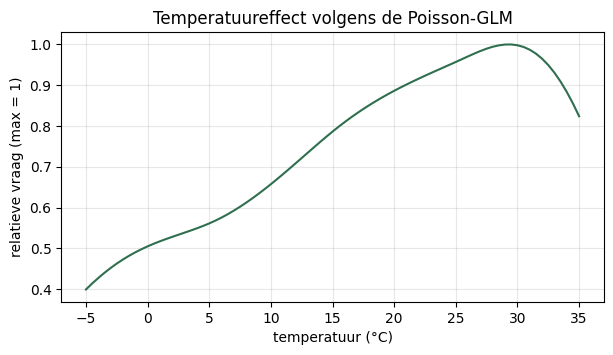

In [6]:
# Temperatuurcurve: de spline laten voorspellen voor -5..35 °C, alle andere kenmerken vast.
import matplotlib.pyplot as plt

temps = np.linspace(-5, 35, 81)
probe = X_train.iloc[[0] * len(temps)].copy()
probe["temperature_c"] = temps
probe["precipitation_mm"], probe["wind_kmh"] = 0.0, 10.0
curve = best.predict(probe)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(temps, curve / curve.max(), color="#2f6f4f")
ax.set(xlabel="temperatuur (°C)", ylabel="relatieve vraag (max = 1)", title="Temperatuureffect volgens de Poisson-GLM")
ax.grid(alpha=.3)
plt.show()

**Interpretatie:** dit is wat een GLM ons "gratis" geeft, effecten die je aan een planner kan uitleggen:
- **Regen**: 1 mm per uur haalt er **30%** af, 5 mm per uur 60%. Dat ligt in lijn met H1 (03: −27% voor een nat uur). Door de `log1p`-vorm moet het effect bij zware regen wel blijven toenemen, terwijl de data in 03 toonde dat het boven 5 mm/u afvlakt. Dat is een beperking van dit model.
- **Feestdag**: **−17%** ten opzichte van een gewone dag op hetzelfde moment.
- **Maand** (bovenop het temperatuureffect!): oktober heeft 1,7 keer de vraag van januari bij dezelfde temperatuur. September tot november zijn de sterkste maanden: forenzen en studenten zijn terug van vakantie. Dit verklaart waarom de piek in 02 §7 niet in juli ligt.
- **Temperatuur**: de vraag stijgt bijna lineair van −5 °C (40% van het maximum) tot een optimum rond **29 °C**, en daalt daarboven (te heet om te fietsen). Precies het niet-lineaire verband waarvoor we een spline gebruiken.

## 5. Eindtest

In [7]:
cv = cb.cv_scores(best, X_train, y_train, g_train)
pred = best.predict(X_test)
test_metrics = cb.evaluate(y_test, pred)
metrics = {"notebook": "05c_poisson_glm", "model": "Poisson-GLM (zone x uur x weekend, spline temperatuur)",
           "params": {"alpha": search.best_params_["poissonregressor__alpha"]},
           "rain_factor_1mm": round(float(np.exp(rain_coef * np.log1p(1) / sd)), 3),
           "holiday_factor": round(float(holiday), 3),
           **cv, **{f"test_{k}": v for k, v in test_metrics.items()}}
cb.save_results("poisson_glm", metrics, table.loc[y_test.index, ["zone", "time", "trips"]].assign(pred=pred),
                cb.METRICS_2024, cb.PRED_2024)
test_metrics

{'mae': 33.1892, 'rmse': 60.3971, 'r2': 0.8916, 'poisson_deviance': 14.5894}

## Samenvatting
| Variant | CV-MAE | Test-MAE | Test-R² |
|---|---|---|---|
| additief | 37,3 | | |
| zone × uur × weekend, `alpha = 1e-6` | 30,5 | 33,2 | 0,89 |

- Een lineair model haalt met de juiste interactie al **R² 0,89**, ruim beter dan de baseline (MAE 59), maar minder goed dan gradient boosting (05e). Het mist interacties die we niet zelf bouwden (bv. regen × weekend: in 02 §7 was het weekend gevoeliger voor regen).
- De **meerwaarde** van dit model zit in de uitleg: de factoren hierboven gebruiken we in de presentatie om te tonen *waarom* de vraag schommelt.